# makemore_Backprop（反向传播实战）

----
* 灵感来源于 Andrej Karpathy 的视频教程 ["Building makemore Part 4: Becoming a Backprop Ninja"](https://www.youtube.com/watch?v=q8SA3rM6ckI&t=6s)

* 实用链接
    - [交叉熵损失 (Cross-Entropy Loss)](https://en.wikipedia.org/wiki/Cross-entropy)
    - [贝塞尔校正 (Bessel's Correction)](https://en.wikipedia.org/wiki/Bessel%27s_correction)
    - [批标准化论文 (Batch Normalization Paper)](https://arxiv.org/abs/1502.03167)

# 目录
------------------
- [0. Makemore 简介](#0)
- [1. 初始代码](#1)
- [2. 练习 1：通过原子计算图进行反向传播](#2)
- [3. `BatchNorm` 中的贝塞尔校正](#3)
- [4. 练习 2：交叉熵损失反向传播](#4)
- [5. 练习 3：`BatchNorm` 层反向传播](#5)
- [6. 练习 4：融会贯通与整体训练](#6)
- [7. 总结](#7)
- [附录](#a1)
    - [A1. 线性层手动反向传播：简化案例](#a1)
    - [A2. 广播机制示例：简化案例](#a2)
- [参考文献](#r1)

-----------
<br><br>
# 0. Makemore: 简介<a id="0"></a>
---------------------------------
<u>**Makemore**</u> 以一个文本文件作为输入，其中每一行被视为一个训练样本，并生成更多类似的文本。其底层是一个**自回归字符级语言模型**，支持从 Bigram 到 Transformer（与 GPT 中完全一致）的<u>多种模型架构选择</u>。[自回归模型](https://en.wikipedia.org/wiki/Autoregressive_model)规定输出变量线性依赖于其自身的前序值和一个随机项（不可完美预测的项）。例如，我们可以向其输入一个人名数据库，makemore 就会生成听起来很像名字但尚未存在的全新起名创意；或者输入一个公司名数据库，生成新的公司起名想法；或者输入有效的拼字游戏单词，生成类似英语的胡言乱语。
```
"正如其名字所暗示的，makemore 制造更多。"
```
这并不是一个带有十亿个开关和旋钮的庞大重型库。它是一个易于 hack 的单文件项目，主要用于教学目的。[PyTorch](https://pytorch.org) 是唯一的依赖项。

当前的实现遵循了几篇关键论文：

- Bigram（用频次查找表由一个字符预测下一个字符）
- MLP，参考 [Bengio 等人 2003](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)
- CNN，参考 [DeepMind WaveNet 2016](https://arxiv.org/abs/1609.03499)（进行中...）
- RNN，参考 [Mikolov 等人 2010](https://www.fit.vutbr.cz/research/groups/speech/publi/2010/mikolov_interspeech2010_IS100722.pdf)
- LSTM，参考 [Graves 等人 2014](https://arxiv.org/abs/1308.0850)
- GRU，参考 [Kyunghyun Cho 等人 2014](https://arxiv.org/abs/1409.1259)
- Transformer，参考 [Vaswani 等人 2017](https://arxiv.org/abs/1706.03762)


在第 3 篇 makemore 教程 Notebook 中，我们介绍了训练神经网络的关键概念，包括前向传播激活值、反向传播梯度和批标准化（Batch Normalization），重点是在 `PyTorch` 中实现和优化 MLP 与 ResNet。我们还介绍了用于监控神经网络健康状况的诊断工具，并强调了合理初始化权重和选择学习率等重要考量。



在本 Notebook 中，我们将沿用上一个视频中的 **2 层 MLP（带 BatchNorm）**，并**<u>纯手动</u>对其进行反向传播，不使用 `PyTorch` autograd 的 `loss.backward()`，逐步穿过交叉熵损失、第 2 个 `Linear` 层、`tanh`、`batchnorm`、第 1 个 `Linear` 层以及嵌入表。** 在此过程中，我们将建立起对梯度如何在计算图中反向流动、以及在高效张量级别（而非像 **micrograd** 中仅针对单个标量）流动的深刻直观理解。这将有助于建立对神经网络优化的扎实能力和直觉，使你能够更有信心地对现代神经网络进行创新和调试。

---------
<br><br><a id="1"></a>
# 1. 初始代码
-----
让我们回顾在 **makemore 系列第 2 与第 3 部分（MLP）** 中实现的 MLP 模型。

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # 用于绘图
%matplotlib inline

In [2]:
# 读取所有单词
words = open('../data/names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# 构建字符词表以及与整数之间的双向映射
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# 构建数据集
block_size = 3 # 上下文长度：用多少个字符来预测下一个字符？

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # 裁剪并追加

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


----
`cmp` 函数将用于比对并检查手动计算的梯度与 `PyTorch` 自动求导计算的梯度。

In [5]:
# 工具函数：用于后续比对我们手动计算的梯度与 PyTorch 的梯度
def cmp(s, dt, t):
    ex = torch.all(dt == t.grad).item()
    app = torch.allclose(dt, t.grad)
    maxdiff = (dt - t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [6]:
n_embd = 10 # 字符嵌入向量维度
n_hidden = 64 # MLP 隐藏层神经元数量

g = torch.Generator().manual_seed(2147483647) # 保证实验可复现
C  = torch.randn((vocab_size, n_embd),            generator=g)
# 第 1 层
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # 这里加上 b1 只是为了演示，实际上因为 BN 的存在它是多余的
# 第 2 层
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm 参数
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# 注意：这里有许多参数采用了非标准方式初始化
# 因为使用全零等方式初始化，有时会掩盖错误的
# 反向传播实现。

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # 参数总数
for p in parameters:
    p.requires_grad = True

4137


In [7]:
batch_size = 32
n = batch_size # 同时使用一个更短的变量名，便于书写
# 构建小批量（minibatch）
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # 批量的 X, Y

----
我们将实现一个大幅展开的前向传播版本，原因如下：
* 完整显式地实现损失函数，而不是直接调用 `F.cross_entropy`
* 将实现拆解为易于管理的原子计算小块
    - 允许我们自底向上（从后向前）一步步手动计算各步骤的梯度

In [8]:
# 前向传播：拆解为微小的原子步骤，以便能够一步步单独进行反向传播

emb = C[Xb] # 将字符嵌入为向量
embcat = emb.view(emb.shape[0], -1) # 拼接向量
# 线性层 1
hprebn = embcat @ W1 + b1 # 隐藏层预激活
# BatchNorm 层
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # 注意：贝塞尔校正（除以 n-1 而不是 n）
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# 非线性激活
h = torch.tanh(hpreact) # 隐藏层
# 线性层 2
logits = h @ W2 + b2 # 输出层
# 交叉熵损失（等价于 F.cross_entropy(logits, Yb)）
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # 减去最大值以保证数值稳定性（防止指数爆炸）
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # 如果使用 (1.0 / counts_sum)，反向传播在位精度上无法做到完全一致...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch 反向传播
for p in parameters:
    p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # 据我所知没有更简洁的写法了
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
    t.retain_grad()
loss.backward()
loss

tensor(3.3453, grad_fn=<NegBackward0>)

---------
<br><br><a id="2"></a>
# 2.  练习 1：通过原子计算图进行反向传播
-----
目标是逐步手动计算损失相对于所有前序参数/变量的梯度。让我们逐一分析各个变量。[注意：对所有网络参数，记 `di = dloss/di`]
* `dlogprobs` = `torch.zeros_like(logprobs)` $\rightarrow$ `dlogprobs[range(n), Yb]` = `-1.0/n`
    - 计算 `loss` 时，我们仅从 `logprobs` 矩阵中取出目标字符对应的项。因此，只有这些位置（目标位置）会受到反向传播的影响。由于我们在小批量上取平均值，因此必须除以小批量大小（`n` = $32$）。
    - 简化示例：使用 `loss = -(a+b+c)/3`（其中 `n` = $3$），则 `dloss/da = dloss/db = dloss/dc = -1/3`
    - 有关广播机制的说明请参见 [附录 A2](#a2)。
<br><br>   
* `dprobs` = `(1/probs) * dlogprobs` 
    - 如果 `prob` 非常接近 $1$（正确预测），则直接传递 `dlogprobs`；如果给正确字符分配了较低的 `prob`（错误预测），则会放大该梯度的惩罚力度。
    - 利用 $\boldsymbol{\frac{d\ln(x)}{dx} = \frac{1}{x}}$ 以及<u>链式法则</u>：$\boldsymbol{\frac{dy}{dx} = \frac{d\ln(x)}{dx} \times \frac{dy}{d\ln(x)}}$
<br><br>    
* `dcounts_sum_inv` = `(counts * dprobs).sum(1, keepdim = True)`
    - `counts_sum_inv` 是 $[32, 1]$ 矩阵，而 `counts` 是 $[32, 27]$ 矩阵。底层发生了**广播机制（broadcasting）**。来看一个简单示例：<br><img src="_imgs/dcounts_sum_inv_broadcasting.png" alt="broadcasting" width="500" ><br> 由于 $b1$ 出现在结果矩阵的多个位置，我们必须累加这些梯度。因此，必须沿行方向对梯度矩阵求和（`.sum(1, keepdim = True)`）。
    - 牢记：**前向传播中的广播在反向传播中对应求和。** 参见 [附录 A2](#a2)。
    - 利用 $\boldsymbol{f = a\times b, \frac{df}{da} = b}$ 以及<u>链式法则</u>：$\boldsymbol{\frac{dy}{da} = \frac{df}{da} \times \frac{dy}{df}}$
  <br><br>  
* `dcounts_sum` = `(-counts_sum**-2) * dcounts_sum_inv`
    - 利用 $\boldsymbol{\frac{dx^n}{dx} = nx^{(n-1)}}$ 以及<u>链式法则</u>：$\boldsymbol{\frac{dy}{dx} = \frac{dx^n}{dx} \times \frac{dy}{dx^n}}$
<br><br>    
* `dcounts` = `dprobs * counts_sum_inv` $\rightarrow$ `dcounts += torch.ones_like(counts)* dcounts_sum`
    - 利用 $\boldsymbol{f = a\times b, \frac{df}{da} = b}$ 以及<u>链式法则</u>：$\boldsymbol{\frac{dy}{da} = \frac{df}{da} \times \frac{dy}{df}}$
    - `count` 通过如下所示的两条路径对导数做出贡献，因此必须将两部分的导数相加。在 `counts_sum` 中，我们对 `count` 沿行求和。**前向传播中的求和在反向传播中对应广播。** 参见 [附录 A2](#a2)。<br>
        ```
        >>>probs = counts * counts_sum_inv
        >>>counts_sum = counts.sum(1, keepdims=True)
        ```
    - 上述代码展示了前向传播中与 `counts` 相关的代码部分。
<br><br>
* `dnorm_logits` = `norm_logits.exp() * dcounts`
    - 利用 $\boldsymbol{\frac{de^{x}}{dx} = e^{x}}$ 以及<u>链式法则</u>：$\boldsymbol{\frac{dy}{dx} = \frac{de^x}{dx} \times \frac{dy}{de^x}}$
<br><br> 
* `dlogit_maxes` = `(-1.0 * dnorm_logits).sum(1, keepdim = True)`
    - 利用 $\boldsymbol{f = a - b, \frac{df}{db} = -1}$ 以及<u>链式法则</u>：$\boldsymbol{\frac{dy}{db} = \frac{df}{db} \times \frac{dy}{df}}$
    - `logits` 和 `logit_maxes` 的形状分别为 $[32, 27]$ 和 $[32, 1]$。`logit_maxes` 矩阵**沿行进行了广播。** 因此，我们必须累加梯度（沿行对梯度矩阵求和）。由于这是简单的加减法，梯度直接回传。
    - `logit_maxes` 不会改变概率的整体相对分布，仅用于数值稳定性。因此 `dlogit_maxes` 的值必须非常接近 $0$。
<br><br>     
* `dlogits` = `1 * dnorm_logits` $\rightarrow$ `dlogits += F.one_hot(logits.max(1).indices, num_classes = 27) * dlogit_maxes`
    - 利用 $\boldsymbol{f = a - b, \frac{df}{da} = 1}$ 以及<u>链式法则</u>：$\boldsymbol{\frac{dy}{da} = \frac{df}{da} \times \frac{dy}{df}}$
    - Logits 通过两种方式影响前向传播：<br>
        ```
        >>>logit_maxes = logits.max(1, keepdim=True).values
        >>>norm_logits = logits - logit_maxes
        ```
    - `.max` 函数同时返回最大值及其对应位置。只有最大值所在位置才会受到 `logit_maxes` 路径的影响。
    - 参见 [附录 A2](#a2)。
<br><br>     
* `dh` = `dlogits @ W2.T`, `dW2` = `h.T @ dlogits`, `db2` = `dlogits.sum(0)`
    - 参见 [附录 A1](#a1)。
<br><br>    
* `dhpreact` = `(1 - h**2) * dh`
    - 利用 $\boldsymbol{f = \tanh(x), \frac{df}{dx} = 1 - f^2(x)}$ 以及<u>链式法则</u>：$\boldsymbol{\frac{dy}{dx} = \frac{df}{dx} \times \frac{dy}{df}}$
<br><br> 
* `dbngain` = `(bnraw * dhpreact).sum(0, keepdim=True)` $\rightarrow$ `dbnbias` = `(1 * dhpreact).sum(0, keepdim=True)`
    - `bngain` 和 `bnbias` 均为 $[1, 64]$ 矩阵，`bnraw` 是 $[32, 64]$ 矩阵。`bngain` 和 `bnbias` 矩阵**沿列进行了广播。** 因此，我们必须累加梯度（沿列对梯度矩阵求和）。
    - 利用 $\boldsymbol{f = (a\times b) + c, \frac{df}{da} = b, \frac{df}{dc} = 1}$ 以及<u>链式法则</u>：$\boldsymbol{\frac{dy}{da} = \frac{df}{da} \times \frac{dy}{df}}$、$\boldsymbol{\frac{dy}{dc} = \frac{df}{dc} \times \frac{dy}{df}}$
<br><br> 
* `dbnraw` = `bngain * dhpreact`
    - 利用 $\boldsymbol{f = (a\times b), \frac{df}{da} = b}$ 以及<u>链式法则</u>：$\boldsymbol{\frac{dy}{da} = \frac{df}{da} \times \frac{dy}{df}}$
<br><br> 
* `dbnvar_inv` = `(bndiff * dbnraw).sum(0, keepdim=True)`
    - `bnvar_inv` 是 $[1, 64]$ 矩阵，`bndiff` 是 $[32, 64]$ 矩阵。因此 `bnvar_inv` 矩阵**沿列进行了广播。** 我们必须累加梯度（沿列对梯度矩阵求和）。
    - 利用 $\boldsymbol{f = (a\times b), \frac{df}{da} = b}$ 以及<u>链式法则</u>：$\boldsymbol{\frac{dy}{da} = \frac{df}{da} \times \frac{dy}{df}}$
<br><br> 
* `dbnvar` = `-0.5*(bnvar + 1e-5)**(-1.5) * dbnvar_inv`
    - 利用 $\boldsymbol{\frac{dx^n}{dx} = nx^{(n-1)}}$ 以及<u>链式法则</u>：$\boldsymbol{\frac{dy}{dx} = \frac{dx^n}{dx} \times \frac{dy}{dx^n}}$
<br><br> 
* `dbndiff2` = `(1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar`
    - 利用 $\boldsymbol{f = \frac{a}{const + 1}, \frac{df}{da} = \frac{1}{const + 1}}$ 以及<u>链式法则</u>：$\boldsymbol{\frac{dy}{da} = \frac{df}{da} \times \frac{dy}{df}}$
    - `bndiff2` 是 $[32, 64]$ 矩阵，`bnvar` 是 $[1, 64]$ 矩阵。因此必须将两项相乘并加上广播。在 `bnvar` 中，我们对 `bndiff2` 沿行求和。**前向传播中的求和在反向传播中对应广播。** 我们可以使用<u>全 1 矩阵来实现广播操作。</u><br>
        ```
        >>>bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True)
        ```
    - 上述代码展示了前向传播中与 `bndiff2` 相关的代码部分。
<br><br> 
* `dbndiff` = `(bnvar_inv * dbnraw) + (2 * bndiff * dbndiff2)`
    - `bndiff` 通过如下所示的两条路径对导数做出贡献，因此必须将两部分的导数相加。回顾<u>多元链式法则：</u> $\boldsymbol{ \frac{df}{dt} = \frac{df}{da}\frac{da}{dt} + \frac{df}{db}\frac{db}{dt}  }$ <br>
        ```
        >>>bndiff2 = bndiff**2
        >>>bnraw = bndiff * bnvar_inv
        ```
    - 上述代码展示了前向传播中与 `bndiff` 相关的代码部分。
<br><br> 
* `dbnmeani` = `(-1.0 * dbndiff).sum(0, keepdim=True)`
    - 参考 `dbnbias` 和 `dbnvar_inv` 小节
<br><br>
* `dhprebn` = `1.0 * dbndiff` $\rightarrow$ `dhprebn += (1.0/n) * torch.ones_like(hprebn) * dbnmeani`
    - 参考 `dlogits` 和 `dbndiff2` 小节
<br><br>
* `dembcat` = `dhprebn @ W1.T`, `dW1` = `embcat.T @ dhprebn`, `db1` = `dhprebn.sum(0)`
    - 参见 [附录 A1](#a1)
<br><br>
* `demb` = `dembcat.view(emb.shape)`
    - 由于我们在前向时对嵌入向量进行了拼接，反向时需要对梯度进行解包。我们可以使用 `.view` 操作。<br>
        ```
        >>>embcat = emb.view(emb.shape[0], -1) 
        ```
    - 上述代码展示了前向传播中与 `emb` 相关的代码部分。
<br><br> 
* `dC` 
    - 这个梯度稍微更棘手一些。我们基本上必须将嵌入梯度流回原始的嵌入查找表空间。
    - `emb.shape = [32,3,10]` 且 `C.shape = [27,10]`。
    - 处理此问题的一种方法是<u>遍历 `Xb` 的行和列，将每个嵌入梯度映射并累加到对应的嵌入向量上。</u>
    - 同时请注意，某些嵌入位置可能会出现多次，因此在这些情况下我们必须累加梯度。

In [9]:
Yb

tensor([ 8, 14, 15, 22,  0, 19,  9, 14,  5,  1, 20,  3,  8, 14, 12,  0, 11,  0,
        26,  9, 25,  0,  1,  1,  7, 18,  9,  3,  5,  9,  0, 18])

In [10]:
logprobs.shape

torch.Size([32, 27])

In [11]:
logprobs[range(n), Yb]

tensor([-4.0235, -3.1084, -3.7720, -3.3151, -4.1176, -3.4518, -3.1585, -4.0307,
        -3.1968, -4.2255, -3.1685, -1.6564, -2.8270, -3.0631, -3.0935, -3.2368,
        -3.8344, -2.9657, -3.6369, -3.3690, -2.8689, -2.9952, -4.3148, -3.9972,
        -3.4332, -2.8502, -3.0326, -3.8626, -2.6536, -3.4266, -3.3391, -3.0239],
       grad_fn=<IndexBackward0>)

In [12]:
logprobs[range(n), Yb].shape

torch.Size([32])

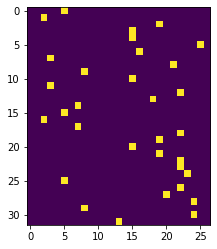

In [13]:
# 查看最大值所在的位置
plt.imshow(F.one_hot(logits.max(1).indices, num_classes = logits.shape[1]))
plt.show()

In [14]:
#counts.shape, counts_sum_inv.shape, dprobs.shape

In [15]:
counts_sum.shape, counts.shape

(torch.Size([32, 1]), torch.Size([32, 27]))

In [16]:
norm_logits.shape, logit_maxes.shape, logits.shape

(torch.Size([32, 27]), torch.Size([32, 1]), torch.Size([32, 27]))

In [17]:
# dlogits.shape, h.shape, W2.shape, b2.shape

In [18]:
#dhpreact.shape, bngain.shape, bnbias.shape, bnraw.shape, (bngain * dhpreact).shape

In [19]:
#bnraw.shape, bndiff.shape, bnvar_inv.shape, (bndiff*dbnraw).sum(0, keepdim=True).shape

In [20]:
#bnvar_inv.shape, bnvar.shape,(-0.5*bnvar_inv**3 * dbnvar_inv).shape

In [21]:
bnvar.shape, bndiff2.shape

(torch.Size([1, 64]), torch.Size([32, 64]))

In [22]:
#bndiff.shape, (bnvar_inv * dbnraw).shape, (2*bndiff*dbndiff2).shape

In [23]:
#bndiff.shape, hprebn.shape, bnmeani.shape, (-1*dbndiff).sum(0, keepdim=True).shape

In [24]:
#bnmeani.shape, hprebn.shape, (torch.ones_like(hprebn)*dbndiff).shape, ((1.0/n) * torch.ones_like(hprebn) * dbnmeani).shape

In [25]:
# hprebn.shape, \
# embcat.shape, (dhprebn @ W1.T).shape, \
# W1.shape, (embcat.T @ dhprebn).shape, \
# b1.shape, dhprebn.sum(0).shape

In [26]:
#embcat.shape, emb.shape, dembcat.view(emb.shape).shape

In [27]:
#emb.shape, C.shape, Xb.shape, demb.shape

In [28]:
# 练习 1：手动对整个计算图进行反向传播， 
# 严格按照上面前向传播中定义的每一个变量， 
# 一步一步逐个反向传播梯度

# -----------------
# 在此处编写代码 :)
# -----------------
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n
dprobs = (1.0 / probs) * dlogprobs
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim = True)
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
dcounts = counts_sum_inv * dprobs
dcounts += torch.ones_like(counts)* dcounts_sum
dnorm_logits = norm_logits.exp() * dcounts
dlogit_maxes = (-1.0 * dnorm_logits).sum(1, keepdim = True)
dlogits = dnorm_logits.clone()
dlogits += F.one_hot(logits.max(1).indices, num_classes = logits.shape[1]) * dlogit_maxes
# dlogits2 = torch.zeros_like(logits)
# dlogits2[range(logits.shape[0]), logits.max(1).indices] = 1.0
# dlogits += dlogits2 * dlogit_maxes
dh = dlogits @ W2.T # [32 27] * [27 64] -> [32 64]
dW2 = h.T @ dlogits # [64 32] * [32 27] -> [64 27]
db2 = dlogits.sum(0) # [32 27].sum(0) -> [27]
dhpreact = (1.0 - h**2) * dh
dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
dbnbias = (1.0 * dhpreact).sum(0, keepdim=True)
dbnraw = bngain * dhpreact
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
dbnvar = -0.5*(bnvar + 1e-5)**(-1.5) * dbnvar_inv
dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
dbndiff = (bnvar_inv * dbnraw) + (2 * bndiff * dbndiff2)
dbnmeani = (-1.0 * dbndiff).sum(0, keepdim=True)
dhprebn = dbndiff.clone() #torch.ones_like(hprebn) * dbndiff
dhprebn += (1.0/n) * (torch.ones_like(hprebn) * dbnmeani)
dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)
demb = dembcat.view(emb.shape)
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]


cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

---------
<br><br><a id="3"></a>
# 3.  `BatchNorm` 中的贝塞尔校正 (Bessel's Correction)
-----
注意到我们在 <u>BatchNorm 的实现</u> 中使用了与传统方差定义不同的公式。这被称为**贝塞尔校正（Bessel's correction）**。当我们从总体分布中抽取一个批次并计算该批次的样本方差时，必须将平方差之和除以 $n-1$（其中 $n$ 为批大小）。除以 $n$ 会得到有偏估计，从而引入训练-测试不匹配（train-test mismatch）。当训练时使用有偏版本而在推理阶段（估计滑动标准差）使用无偏估计时，就会产生这种训练-测试不匹配/偏差。
```
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True)
```

---------
<br><br><a id="4"></a>
# 4.  练习 2：交叉熵损失反向传播（一步到位）
-----

In [29]:
# 练习 2：一步到位实现 cross_entropy 的反向传播
# 要完成这个挑战，请观察损失函数的数学表达式，
# 求导、化简表达式，然后直接写出结果

# 前向传播

# 之前：
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # 减去最大值以保证数值稳定性
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # 如果使用 (1.0 / counts_sum)，反向传播在位精度上无法做到完全一致...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# 现在：
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.345287322998047 diff: 0.0


In [30]:
# 反向传播

# -----------------
# 在此处编写代码 :)
dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -=1
dlogits /= n
# -----------------

cmp('logits', dlogits, logits) # 近似相等即可（approximate 为 True），我的 maxdiff 大约是 6e-9

logits          | exact: False | approximate: True  | maxdiff: 7.683411240577698e-09


In [31]:
dlogits[31]

tensor([ 0.0014,  0.0007,  0.0020,  0.0006,  0.0024,  0.0009,  0.0005,  0.0008,
         0.0005,  0.0016,  0.0008,  0.0010,  0.0010,  0.0025,  0.0012,  0.0012,
         0.0016,  0.0012, -0.0297,  0.0004,  0.0018,  0.0004,  0.0020,  0.0007,
         0.0007,  0.0013,  0.0006], grad_fn=<SelectBackward0>)

---
让我们深入探究一下 `dlogits`，直观理解其物理意义。事实证明，它有一个非常优美且相当直观的解释。

In [32]:
F.softmax(logits, 1)[0]

tensor([0.0740, 0.0780, 0.0175, 0.0491, 0.0205, 0.0891, 0.0225, 0.0396, 0.0179,
        0.0312, 0.0345, 0.0349, 0.0362, 0.0284, 0.0347, 0.0135, 0.0094, 0.0177,
        0.0173, 0.0552, 0.0488, 0.0235, 0.0251, 0.0712, 0.0626, 0.0253, 0.0222],
       grad_fn=<SelectBackward0>)

In [33]:
dlogits[0] * n

tensor([ 0.0740,  0.0780,  0.0175,  0.0491,  0.0205,  0.0891,  0.0225,  0.0396,
        -0.9821,  0.0312,  0.0345,  0.0349,  0.0362,  0.0284,  0.0347,  0.0135,
         0.0094,  0.0177,  0.0173,  0.0552,  0.0488,  0.0235,  0.0251,  0.0712,
         0.0626,  0.0253,  0.0222], grad_fn=<MulBackward0>)

In [34]:
dlogits[0] * n == F.softmax(logits, 1)[0]

tensor([ True,  True,  True,  True,  True,  True,  True,  True, False,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True])

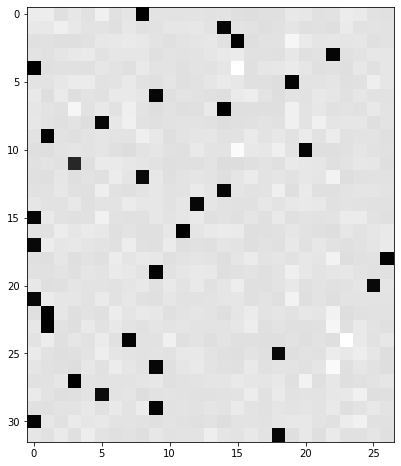

In [35]:
plt.figure(figsize=(8, 8))
plt.imshow(dlogits.detach(), cmap='gray')
plt.show()

`dlogits` 中的每一行元素求和都为 $0$，并且在正确类别索引的位置上，其值接近 $-1$。每个单元格上的梯度就像一种力：我们要么拉低（pull down）错误字符的概率，要么推高（push up）正确索引处的概率。这基本上就是每一行中发生的事情。推和拉的总量是完全相等的，因为每一行的和为 $0$。本质上，排斥力与吸引力大小相等。

这种力的大小与前向传播中输出的概率成正比。如果概率预测完全正确——基本上除正确索引位置为 1 之外其余位置全为 0：`[0, 0, 0, 1, 0, ..., 0]`——那么 `dlogits` 对应的整行都将为 $0$（不存在任何推拉力）。本质上，你的预测偏离正确答案多少，你在该维度上受到的推或拉的力度就是多少。<u>预测错误的程度与推/拉的强度成正比。</u> 这在该张量的所有维度（行）上独立发生。这就是**交叉熵损失**在神经网络反向传播动态机制中的精妙之处。

---------
<br><br><a id="5"></a>
# 5.  练习 3：`BatchNorm` 层反向传播（一步到位）
------ 

In [36]:
# 练习 3：一步到位实现 batchnorm 的反向传播
# 要完成这个挑战，请观察 batchnorm 输出的数学表达式，
# 对输入求偏导，化简表达式，然后直接写出结果
# BatchNorm 论文：https://arxiv.org/abs/1502.03167

# 前向传播

# 之前：
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # 注意：贝塞尔校正（除以 n-1 而不是 n）
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# 现在：
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(4.7684e-07, grad_fn=<MaxBackward1>)


In [37]:
dhpreact.shape, (n*dhpreact).shape, bnraw.sum(0).shape

(torch.Size([32, 64]), torch.Size([32, 64]), torch.Size([64]))

In [38]:
# 反向传播

# 之前我们的写法是：
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# 给定 dhpreact 计算 dhprebn（即对 batchnorm 进行整体反向传播）
# （你还需要用到上面前向传播中的部分变量）

# -----------------
# 在此处编写代码 :)
inside = n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0)
dhprebn = bngain*bnvar_inv/n * inside
# -----------------

cmp('hprebn', dhprebn, hprebn) # 近似相等即可（approximate 为 True），我的 maxdiff 大约是 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


---------
<br><br><a id="6"></a>
# 6.  练习 4：融会贯通与整体训练
------ 

In [39]:
# 练习 4：融会贯通！
# 使用你自己编写的反向传播来训练这个 2 层 MLP 神经网络

# 初始化
n_embd = 10 # 字符嵌入向量维度
n_hidden = 200 # MLP 隐藏层神经元数量

g = torch.Generator().manual_seed(2147483647) # 保证实验可复现
C  = torch.randn((vocab_size, n_embd),            generator=g)
# 第 1 层
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# 第 2 层
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm 参数
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # 参数总数
for p in parameters:
    p.requires_grad = True

# 与上次相同的优化设置
max_steps = 200000
batch_size = 32
n = batch_size # 方便使用
lossi = []

# 编写好反向传播后，可以使用此上下文管理器提高效率（TODO）
with torch.no_grad():

    # 启动优化迭代
    for i in range(max_steps):

        # 构建小批量
        ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
        Xb, Yb = Xtr[ix], Ytr[ix] # 批量的 X, Y

        # 前向传播
        emb = C[Xb] # 将字符嵌入为向量
        embcat = emb.view(emb.shape[0], -1) # 拼接向量
        # 线性层
        hprebn = embcat @ W1 + b1 # 隐藏层预激活
        # BatchNorm 层
        # -------------------------------------------------------------
        bnmean = hprebn.mean(0, keepdim=True)
        bnvar = hprebn.var(0, keepdim=True, unbiased=True)
        bnvar_inv = (bnvar + 1e-5)**-0.5
        bnraw = (hprebn - bnmean) * bnvar_inv
        hpreact = bngain * bnraw + bnbias
        # -------------------------------------------------------------
        # 非线性激活
        h = torch.tanh(hpreact) # 隐藏层
        logits = h @ W2 + b2 # 输出层
        loss = F.cross_entropy(logits, Yb) # 损失函数

        # 反向传播
        for p in parameters:
            p.grad = None
        #loss.backward() # 用于正确性比对，之后请将其删除！

        # 手动反向传播！#肌肉狗meme
        # -----------------
        # 在此处编写代码 :)

        dlogits = F.softmax(logits, 1)
        dlogits[range(n), Yb] -=1
        dlogits /= n

        # 第 2 个线性层反向传播
        dh = dlogits @ W2.T # [32 27] * [27 64] -> [32 64]
        dW2 = h.T @ dlogits # [64 32] * [32 27] -> [64 27]
        db2 = dlogits.sum(0) # [32 27].sum(0) -> [27]

        # tanh 层反向传播
        dhpreact = (1.0 - h**2) * dh

        # batchnorm 层反向传播
        dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
        dbnbias = (1.0 * dhpreact).sum(0, keepdim=True)
        _inside = n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0)
        dhprebn = bngain*bnvar_inv/n * _inside

        # 第 1 个线性层
        dembcat = dhprebn @ W1.T
        dW1 = embcat.T @ dhprebn
        db1 = dhprebn.sum(0)

        # 嵌入层反向传播
        demb = dembcat.view(emb.shape)
        dC = torch.zeros_like(C)
        for k in range(Xb.shape[0]):
            for j in range(Xb.shape[1]):
                ix = Xb[k,j]
                dC[ix] += demb[k,j]
        grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
        # -----------------

        # 参数更新
        lr = 0.1 if i < 100000 else 0.01 # 阶梯式学习率衰减
        for p, grad in zip(parameters, grads):
            #p.data += -lr * p.grad # 弱小狗 Cheems 的旧方式（使用 PyTorch .backward() 得到的梯度）
            p.data += -lr * grad # 肌肉狗 Swole Doge 的全新方式 TODO: 启用

        # 记录统计信息
        if i % 10000 == 0: # 定期打印训练日志
            print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
        lossi.append(loss.log10().item())

    #     if i >= 100: # TODO: delete early breaking when you're ready to train the full net
    #         break

12297
      0/ 200000: 3.8076
  10000/ 200000: 2.1823
  20000/ 200000: 2.3872
  30000/ 200000: 2.4668
  40000/ 200000: 1.9771
  50000/ 200000: 2.3679
  60000/ 200000: 2.3298
  70000/ 200000: 2.0803
  80000/ 200000: 2.3316
  90000/ 200000: 2.1813
 100000/ 200000: 1.9634
 110000/ 200000: 2.3756
 120000/ 200000: 1.9926
 130000/ 200000: 2.4832
 140000/ 200000: 2.2406
 150000/ 200000: 2.2007
 160000/ 200000: 1.9112
 170000/ 200000: 1.8385
 180000/ 200000: 1.9989
 190000/ 200000: 1.8666


In [40]:
# 用于检查梯度的实用代码
# for p,g in zip(parameters, grads):
#     cmp(str(tuple(p.shape)), g, p)

In [41]:
# 训练结束后校准 batch norm 的均值与方差

with torch.no_grad():
    # 将整个训练集前向传入
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # 统计整个训练集上的均值/标准差
    bnmean = hpreact.mean(0, keepdim=True)
    bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [42]:
# 评估训练集和验证集损失

@torch.no_grad() # 该装饰器用于禁用梯度跟踪
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # 拼接为 (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.07059383392334
val 2.1111838817596436


达到的最终损失：
* train（训练集）: $\boldsymbol{2.072}$
* val（验证集）: $\boldsymbol{2.109}$

In [43]:
# 原教程中达到的损失：
# train 2.0718822479248047
# val 2.1162495613098145

In [44]:
# 从模型中采样生成文本
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # 初始化全为 ...
    while True:
        # 前向传播
        emb = C[torch.tensor([context])] # (1,block_size,d)      
        embcat = emb.view(emb.shape[0], -1) # 拼接为 (N, block_size * n_embd)
        hpreact = embcat @ W1 + b1
        hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
        h = torch.tanh(hpreact) # (N, n_hidden)
        logits = h @ W2 + b2 # (N, vocab_size)
        # 采样
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

carlah.
amori.
kifi.
mri.
reetlenna.
sane.
mahnel.
delynn.
jareei.
nellara.
chaiivon.
leigh.
ham.
join.
quint.
shon.
marianni.
watero.
dearynix.
kaellissabeed.


---------
<br><br><a id="7"></a>
# 7. 总结
---

本 Notebook 的核心主旨是纯手动实现反向传播，以计算神经网络所有参数的梯度。本质上，我们不调用 PyTorch autograd 的 `loss.backward()` 函数，而是一步一步手工构建了穿过整个神经网络的完整反向传播链——从交叉熵损失、第 2 个线性层、tanh 激活层、BatchNorm 层、第 1 个线性层，一直到字符嵌入查找表。

-----
<br><br>
# 附录

------
## A1. 线性层手动反向传播：简化案例<a id="a1"></a>
-----

让我们来看一个 `logits = h @ W2 + b2` 的简化案例，可用于推导第 2 个线性层的梯度：`dh`、`dW2`、`db2`。这同样适用于第 1 个线性层 `hprebn = embcat @ W1 + b1` 及其梯度：`dembcat`、`dW1`、`db1`。![](_imgs/dh_dW2_db2_broadcasting3.png) 

------
## A2. 广播机制示例：简化案例<a id="a2"></a>
-----

应用于 `dcounts_sum_inv`
```
probs = counts * counts_sum_inv

c = a * b, 但使用张量
a[3 x 3] * b[3 x 1] ---> c[3 X 3]
|a11*b1 a12*b1 a13*b1|
|a21*b2 a22*b2 a23*b2|
|a31*b3 a32*b3 a33*b3|
```

应用于 `dcounts`
```
counts_sum = counts.sum(1, keepdims=True)
|a11 a12 a13|   ---> b1 (= a11 + a12 + a13)
|a21 a22 a23|   ---> b2 (= a21 + a22 + a23)
|a31 a32 a33|   ---> b3 (= a31 + a32 + a33)
```

应用于 `dlogits`
```
norm_logits = logits - logit_maxes
|c11 c12 c13|   = a11 a12 a13   b1
|c21 c22 c23|   = a21 a22 a23 - b2
|c31 c32 c33|   = a31 a32 a33   b3

例如 c32 = a32 - b3
```

-----
<br><br><a id="r1"></a>
# 参考文献
----
1. "<u>Building makemore Part 4: Becoming a Backprop Ninja</u>" [YouTube 视频](https://www.youtube.com/watch?v=q8SA3rM6ckI&t=6s), 2022 年 10 月.
2. Andrej Karpathy **Makemore** [GitHub 仓库](https://github.com/karpathy/makemore).
3. Andrej Karpathy  **Neural Networks: Zero to Hero** [GitHub 仓库](https://github.com/karpathy/nn-zero-to-hero/tree/master)（配合视频教程的 [Notebook](https://github.com/karpathy/nn-zero-to-hero/blob/master/lectures/makemore/makemore_part4_backprop.ipynb)）.
4. 文章："<u>Become a Backprop Ninja with Andrej Karpathy</u>" - Kavishka Abeywardana, 第 [1](https://medium.com/@kdwa2404/become-a-backprop-ninja-with-andrej-karpathy-part-1-c0dab9867654)、[2](https://medium.com/@kdwa2404/become-a-backprop-ninja-with-andrej-karpathy-part-2-e920cf3ea14c) 部分, 2024 年 3 月.
5. "<u>Yes you should understand backprop</u>" - Andrej Karpathy, [文章](https://karpathy.medium.com/yes-you-should-understand-backprop-e2f06eab496b), 2016 年 12 月.
6. "<u>Bessel's Correction</u>" - 埃默里大学数学与计算机科学系, [学术博客](https://math.oxford.emory.edu/site/math117/besselCorrection/), 2016 年 12 月.
------